In [1]:
import sys
sys.path.append('..')
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
)
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
from loguru import logger
from typing import Callable
from collections import defaultdict
import os

from train_ae import Autoencoder, CTDecoder  # import your trained VAE class
from src.modeling import ProjectionVIT  # import your trained VAE class
from src.data import training_examination_to_tensor

/home/borntowarn/projects/chest-diseases/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/borntowarn/projects/chest-diseases/venv/lib/python3.11/site-packages/vector_quantize_pytorch/vector_quantize_pytorch.py:261: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled = False)
/home/borntowarn/projects/chest-diseases/venv/lib/python3.11/site-packages/vector_quantize_pytorch/vector_quantize_pytorch.py:391: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled = False)


In [3]:
device = 'cuda'

In [4]:
model_ckpt1 = "/home/borntowarn/projects/chest-diseases/training/1000.pt"
model_ckpt2 = "/home/borntowarn/projects/chest-diseases/training/1500.pt"
model_ckpt3 = "/home/borntowarn/projects/chest-diseases/training/1800.pt"
model_ckpt4 = "/home/borntowarn/projects/chest-diseases/training/2300.pt"

In [7]:
model_base = ProjectionVIT()
model_base.load_state_dict(torch.load("/home/borntowarn/projects/chest-diseases/training/weights/CT-RATE/ProjectionVIT_Base_V2.pt"))
model_base.eval()
model_base.cuda()

ProjectionVIT(
  (VIT): CTViT(
    (spatial_rel_pos_bias): ContinuousPositionBias(
      (net): ModuleList(
        (0): Sequential(
          (0): Linear(in_features=2, out_features=512, bias=True)
          (1): LeakyReLU(negative_slope=0.1)
        )
        (1): Sequential(
          (0): Linear(in_features=512, out_features=512, bias=True)
          (1): LeakyReLU(negative_slope=0.1)
        )
        (2): Linear(in_features=512, out_features=8, bias=True)
      )
    )
    (to_patch_emb_first_frame): Sequential(
      (0): Rearrange('b c 1 (h p1) (w p2) -> b 1 h w (c p1 p2)', p1=20, p2=20)
      (1): LayerNorm((400,), eps=1e-05, elementwise_affine=True)
      (2): Linear(in_features=400, out_features=512, bias=True)
      (3): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    )
    (to_patch_emb): Sequential(
      (0): Rearrange('b c (t pt) (h p1) (w p2) -> b t h w (c pt p1 p2)', p1=20, p2=20, pt=10)
      (1): LayerNorm((4000,), eps=1e-05, elementwise_affine=True)
     

In [9]:
decoder1 = CTDecoder()
decoder1.load_state_dict(torch.load("/home/borntowarn/projects/chest-diseases/training/1000.pt"))
decoder1.eval()
decoder1.cuda()

decoder2 = CTDecoder()
decoder2.load_state_dict(torch.load("/home/borntowarn/projects/chest-diseases/training/1500.pt"))
decoder2.eval()
decoder2.cuda()

decoder3 = CTDecoder()
decoder3.load_state_dict(torch.load("/home/borntowarn/projects/chest-diseases/training/1800.pt"))
decoder3.eval()
decoder3.cuda()

decoder4 = CTDecoder()
decoder4.load_state_dict(torch.load("/home/borntowarn/projects/chest-diseases/training/2300.pt"))
decoder4.eval()
decoder4.cuda()

CTDecoder(
  (deconv_layers): Sequential(
    (0): ConvTranspose3d(512, 256, kernel_size=(4, 4, 4), stride=(2, 2, 2), padding=(1, 1, 1))
    (1): BatchNorm3d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): ConvTranspose3d(256, 128, kernel_size=(4, 4, 4), stride=(1, 2, 2), padding=(1, 1, 1))
    (4): BatchNorm3d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): ConvTranspose3d(128, 64, kernel_size=(4, 4, 4), stride=(1, 2, 2), padding=(1, 1, 1))
    (7): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Conv3d(64, 1, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (10): Tanh()
  )
)

In [21]:
from collections import defaultdict

errors = defaultdict(list)
labels = defaultdict(list)

# errors = []
# labels = []
filenames = [
    '/home/borntowarn/projects/chest-diseases/training/data/MosMedData-TEST/norma_anon',
    '/home/borntowarn/projects/chest-diseases/training/data/MosMedData-TEST/pneumonia_anon',
    '/home/borntowarn/projects/chest-diseases/training/data/MosMedData-TEST/pneumotorax_anon',
]
with torch.no_grad():
    for filename in tqdm(filenames):
        x = training_examination_to_tensor(filename)
        latent = model_base(x.unsqueeze(0).cuda())
        latent = latent.permute(0, 4, 1, 2, 3).contiguous()

        for i, model in enumerate([decoder1, decoder2, decoder3, decoder4]):
            recon = model(latent)        # deterministic reconstruction
            recon_error = torch.mean((x - recon.cpu()) ** 2)
            errors[i].append(recon_error.item())
            # labels[i].extend(y.any(dim=-1).cpu().numpy())

  0%|          | 0/3 [00:00<?, ?it/s]2025-10-17 23:47:50.381 | INFO     | src.data:training_examination_to_tensor:169 - Обработка DICOM исследования
2025-10-17 23:47:50.381 | INFO     | src.utils.preprocess:read_ct_series:502 - Чтение КТ-серий из /home/borntowarn/projects/chest-diseases/training/data/MosMedData-TEST/norma_anon
2025-10-17 23:47:50.965 | INFO     | src.utils.preprocess:read_ct_series:532 - Прочитаны КТ-серии из /home/borntowarn/projects/chest-diseases/training/data/MosMedData-TEST/norma_anon; найдено 1 серий
2025-10-17 23:47:50.966 | INFO     | src.utils.preprocess:get_thinnest_slice_series_with_windows_paths_:614 - Поиск серии с минимальной толщиной среза с учётом оконных параметров
2025-10-17 23:47:50.967 | INFO     | src.utils.preprocess:get_thinnest_slice_series_with_windows_paths_:663 - Определена минимальная толщина среза: 1.0 мм
2025-10-17 23:47:50.968 | INFO     | src.utils.preprocess:get_thinnest_slice_series_with_windows_paths_:672 - Параметры окна — WindowCent

получаются разделимая норма и пневмония

In [22]:
errors

defaultdict(list,
            {0: [0.023037342354655266,
              0.03035668469965458,
              0.035165224224328995],
             1: [0.022198494523763657,
              0.029308410361409187,
              0.030286675319075584],
             2: [0.019421910867094994,
              0.027086129412055016,
              0.02876533567905426],
             3: [0.021513210609555244,
              0.028080273419618607,
              0.0314025841653347]})

In [7]:
errors = []
labels = []
with torch.no_grad():
    for x, y in tqdm(dl):
        x = x.to(device)
        mu, _ = vae.encode(x)
        recon = vae.decode(mu)        # deterministic reconstruction
        recon_error = torch.mean((x - recon) ** 2, dim=1)
        errors.extend(recon_error.cpu().numpy())
        labels.extend(y.any(dim=-1).cpu().numpy())

errors = np.array(errors)
# errors = (errors - errors.min()) / (errors.max() - errors.min() + 1e-8)

labels = np.array(labels).astype(int)


100%|██████████| 49/49 [00:00<00:00, 448.17it/s]


In [18]:
import json
data = json.load(open('/home/borntowarn/projects/chest-diseases/training/results.json'))
# data.update(json.load(open('/home/borntowarn/projects/chest-diseases/training/results_pos.json')))
ds = pd.read_csv('/home/borntowarn/projects/chest-diseases/training/data/CT-RATE/dataset/multi_abnormality_labels/valid_predicted_labels.csv')


In [ ]:
errors = []
labels = []

for name, error in data.items():
    errors.append(error[-1]) # берем последнюю модель по global_step
    labels.append(int(any(ds.loc[ds['VolumeName'] == name].iloc[:, 1:].values[0])))


In [26]:
df = pd.DataFrame(data={'label':labels, 'error':errors})

In [27]:
df.error

0      0.147085
1      0.145835
2      0.175236
3      0.175351
4      0.127790
         ...   
96     0.165512
97     0.159143
98     0.133285
99     0.128484
100    0.119361
Name: error, Length: 101, dtype: float64

In [28]:
import pandas as pd
import numpy as np

# Compute descriptive stats
summary = (
    df.groupby('label')['error']
      .agg(['count', 'mean', 'std', 'min', 'median', 'max',
            lambda x: np.percentile(x, 2.5),   # Lower 95% bound
            lambda x: np.percentile(x, 97.5)]) # Upper 95% bound
      .assign(
          iqr=lambda x: x['max'] - x['min'],
          coef_var=lambda x: x['std'] / (x['mean'] + 1e-8)
      )
      .round(4)
)

# Rename columns for clarity
summary.columns = [
    'Count', 'Mean Error', 'Std Dev', 'Min Error', 
    'Median Error', 'Max Error', 'Lower 95%', 'Upper 95%', 
    'IQR', 'Coeff of Var'
]

# Add class label meaning if binary
summary.index = summary.index.map({0: 'No Pathology (0)', 1: 'Pathology (1)'})

summary


,Count,Mean Error,Std Dev,Min Error,Median Error,Max Error,Lower 95%,Upper 95%,IQR,Coeff of Var
label,,,,,,,,,,
No Pathology (0),51,0.1418,0.0187,0.1110,0.1367,0.1910,0.1119,0.1772,0.0800,0.1321
Pathology (1),50,0.1450,0.0173,0.1179,0.1453,0.1904,0.1195,0.1733,0.0725,0.1191


/tmp/ipykernel_90842/1274003343.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


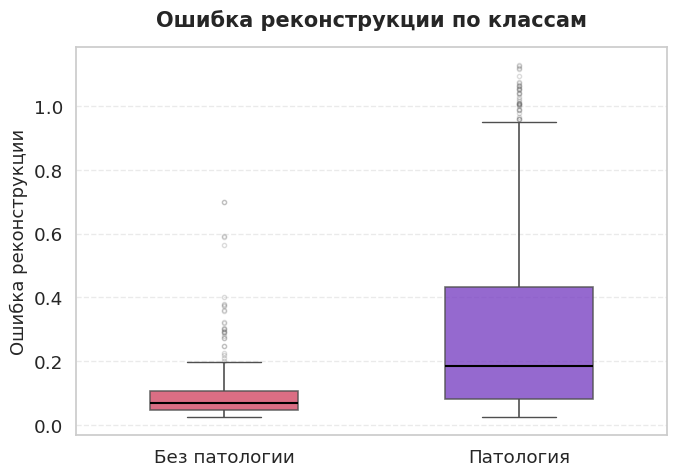

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Custom colors
custom_palette = [(234/255, 51/255, 87/255), (120/255, 45/255, 218/255)]

# Map label names
label_map = {0: "Без патологии", 1: "Патология"}
df['label_name'] = df['label'].map(label_map)

# Styling
sns.set_theme(style="whitegrid", font_scale=1.2)

plt.figure(figsize=(7, 5))

# Boxplot
sns.boxplot(
    data=df,
    x='label_name',
    y='error',
    palette=custom_palette,
    width=0.5,
    showcaps=True,
    boxprops=dict(alpha=0.8, linewidth=1.2),
    medianprops=dict(color='black', linewidth=1.5),
    whiskerprops=dict(linewidth=1.2),
    flierprops=dict(marker='o', markersize=3, alpha=0.2)  # faint outliers
)

# Beautify
plt.title("Ошибка реконструкции по классам", fontsize=15, weight='bold', pad=15)
plt.xlabel("")
plt.ylabel("Ошибка реконструкции", fontsize=13)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()
